# 01 — Analyse Exploratoire des Données (EDA)
## Projet : Home Credit Default Risk — MLOps Pipeline

**Objectif :** Comprendre la structure des données, détecter les anomalies, identifier les features les plus informatives, et préparer la base pour le feature engineering et la modélisation.

**Dataset :** `application_train.csv` — chaque ligne représente une demande de crédit. La cible (`TARGET`) vaut :
- `0` → le client a remboursé correctement
- `1` → le client est en défaut de paiement

---

## 0. Imports et configuration

In [1]:
# ── Librairies standard de data science ──────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Statistiques ──────────────────────────────────────────────────────────────
from scipy import stats

# ── Utilitaires ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Configuration globale des graphiques ──────────────────────────────────────
# On définit un style cohérent pour tout le notebook
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)

# Couleurs du projet (inspirées de la palette SamaFamille → adaptées MLOps)
COLOR_POS = '#E07B4F'   # orange → classe 1 (défaut)
COLOR_NEG = '#2C5F8A'   # bleu   → classe 0 (remboursé)
PALETTE = [COLOR_NEG, COLOR_POS]

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données

> **Pourquoi `low_memory=False` ?**  
> Par défaut, pandas lit par blocs et peut mal inférer les types (ex : une colonne numérique devient `object` si elle contient des valeurs manquantes mixées). `low_memory=False` force la lecture complète avant l'inférence de type.

In [6]:
import os
print(os.getcwd())

C:\Users\Frank\Desktop\home-credit-MLOPS\notebooks


In [7]:
df = pd.read_csv(r'C:\Users\Frank\Desktop\home-credit-MLOPS\data\raw\application_train.csv', low_memory=False)
print(f'📦 Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'💾 Mémoire utilisée : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

📦 Dataset chargé : 307,511 lignes × 122 colonnes
💾 Mémoire utilisée : 529.5 MB


## 2. Vue d'ensemble — structure du dataset

In [8]:
# ── Aperçu des 5 premières lignes ─────────────────────────────────────────────
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# ── Types de données par colonne ──────────────────────────────────────────────
# On distingue les colonnes numériques des catégorielles — traitement différent plus tard
dtype_counts = df.dtypes.value_counts()
print('Types de données :')
print(dtype_counts)

num_cols   = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols   = df.select_dtypes(include=['object']).columns.tolist()

print(f'\n📊 Colonnes numériques : {len(num_cols)}')
print(f'🔤 Colonnes catégorielles : {len(cat_cols)}')

Types de données :
float64    65
int64      41
object     16
Name: count, dtype: int64

📊 Colonnes numériques : 106
🔤 Colonnes catégorielles : 16


In [11]:
# ── Résumé statistique des colonnes numériques ────────────────────────────────
# count, mean, std, min, quartiles, max
# Utile pour repérer des valeurs aberrantes (ex : AMT_INCOME_TOTAL très élevé)
df[num_cols].describe().T.sort_values('mean', ascending=False).head(5)

,count,mean,std,min,25%,50%,75%,max
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0


## 3. Analyse de la variable cible (TARGET)

La variable cible `TARGET` définit si un client est en **défaut de paiement** (1) ou non (0).  
Cette analyse est cruciale car un fort déséquilibre des classes impacte directement le choix des algorithmes et des métriques d'évaluation.

Distribution de TARGET :
  Classe 0 — Remboursé (OK) :  282,686 (91.93%)
  Classe 1 — Défaut (risque) :   24,825 (8.07%)


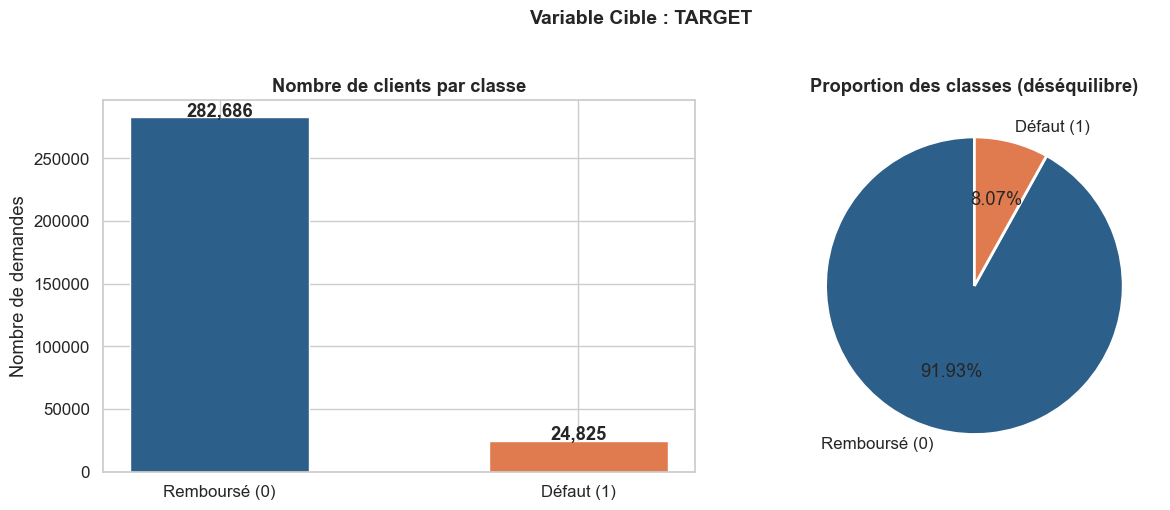

In [12]:
# ── Distribution de la variable cible ────────────────────────────────────────
target_counts = df['TARGET'].value_counts()
target_pct    = df['TARGET'].value_counts(normalize=True) * 100

print('Distribution de TARGET :')
for cls, cnt, pct in zip(target_counts.index, target_counts, target_pct):
    label = 'Défaut (risque)' if cls == 1 else 'Remboursé (OK)'
    print(f'  Classe {cls} — {label} : {cnt:>8,} ({pct:.2f}%)')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot
axes[0].bar(['Remboursé (0)', 'Défaut (1)'], target_counts, color=PALETTE, edgecolor='white', width=0.5)
axes[0].set_title('Nombre de clients par classe', fontweight='bold')
axes[0].set_ylabel('Nombre de demandes')
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts, labels=['Remboursé (0)', 'Défaut (1)'],
            colors=PALETTE, autopct='%1.2f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion des classes (déséquilibre)', fontweight='bold')

plt.suptitle('Variable Cible : TARGET', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 🔎 INTERPRÉTATION
# Le dataset est très déséquilibré : ~92% classe 0 vs ~8% classe 1.
# Conséquences :
#   → Un modèle naïf (prédit toujours 0) atteindrait 92% d'accuracy !
#     C'est pourquoi l'accuracy seule est une mauvaise métrique ici.
#   → Nous utiliserons : AUC-ROC, F1-score (pondéré), et un Score Métier
#     qui pénalise davantage les faux négatifs (manquer un client en défaut)
#     que les faux positifs (refuser un bon client).
#   → Techniques de rééquilibrage à appliquer : SMOTE, class_weight='balanced'
# ─────────────────────────────────────────────────────────────────────────────

## 4. Analyse des valeurs manquantes

Les valeurs manquantes peuvent biaiser le modèle si elles ne sont pas traitées. On distingue :
- **MCAR** (Missing Completely At Random) → imputation simple
- **MAR** (Missing At Random) → imputation conditionnelle
- **MNAR** (Missing Not At Random) → indicateur binaire à créer

In [13]:
# ── Calcul du taux de valeurs manquantes ──────────────────────────────────────
missing = pd.DataFrame({
    'n_missing' : df.isnull().sum(),
    'pct_missing': df.isnull().mean() * 100
}).sort_values('pct_missing', ascending=False)

missing_nonzero = missing[missing['n_missing'] > 0]

print(f'Colonnes avec valeurs manquantes : {len(missing_nonzero)} / {df.shape[1]}')
print(f'\nTop 20 colonnes les plus incomplètes :')
print(missing_nonzero.head(20).to_string())

Colonnes avec valeurs manquantes : 67 / 122

Top 20 colonnes les plus incomplètes :
                          n_missing  pct_missing
COMMONAREA_MEDI              214865    69.872297
COMMONAREA_AVG               214865    69.872297
COMMONAREA_MODE              214865    69.872297
NONLIVINGAPARTMENTS_MODE     213514    69.432963
NONLIVINGAPARTMENTS_AVG      213514    69.432963
NONLIVINGAPARTMENTS_MEDI     213514    69.432963
FONDKAPREMONT_MODE           210295    68.386172
LIVINGAPARTMENTS_MODE        210199    68.354953
LIVINGAPARTMENTS_AVG         210199    68.354953
LIVINGAPARTMENTS_MEDI        210199    68.354953
FLOORSMIN_AVG                208642    67.848630
FLOORSMIN_MODE               208642    67.848630
FLOORSMIN_MEDI               208642    67.848630
YEARS_BUILD_MEDI             204488    66.497784
YEARS_BUILD_MODE             204488    66.497784
YEARS_BUILD_AVG              204488    66.497784
OWN_CAR_AGE                  202929    65.990810
LANDAREA_MEDI                18259

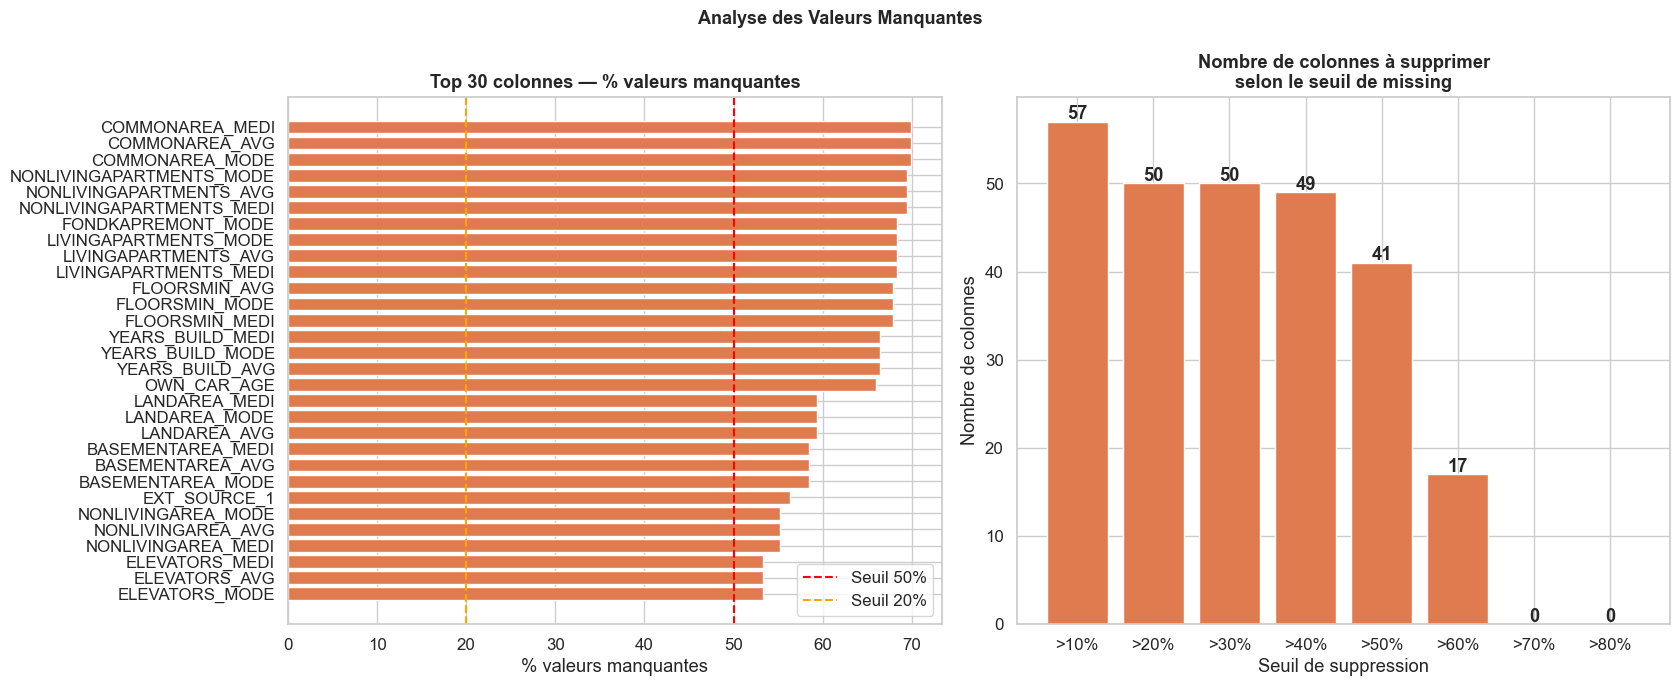

In [15]:
# ── Heatmap des valeurs manquantes (top 40 colonnes) ─────────────────────────
# Permet de repérer des patterns : si deux colonnes ont des NA aux mêmes lignes,
# elles peuvent être liées (ex : OCCUPATION_TYPE et ORGANIZATION_TYPE)
import os
os.makedirs('../data/processed', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Barh top 30 colonnes
top30 = missing_nonzero.head(30)
colors_bar = ['#E07B4F' if v > 50 else '#F0B48A' if v > 20 else '#2C5F8A' 
              for v in top30['pct_missing']]
axes[0].barh(top30.index[::-1], top30['pct_missing'][::-1], 
             color=colors_bar[::-1], edgecolor='white')
axes[0].axvline(50, color='red', linestyle='--', linewidth=1.5, label='Seuil 50%')
axes[0].axvline(20, color='orange', linestyle='--', linewidth=1.5, label='Seuil 20%')
axes[0].set_title('Top 30 colonnes — % valeurs manquantes', fontweight='bold')
axes[0].set_xlabel('% valeurs manquantes')
axes[0].legend()

# Distribution par seuil
seuils = [10, 20, 30, 40, 50, 60, 70, 80]
counts = [(missing['pct_missing'] > s).sum() for s in seuils]
axes[1].bar([f'>{s}%' for s in seuils], counts, color='#E07B4F', edgecolor='white')
axes[1].set_title('Nombre de colonnes à supprimer\nselon le seuil de missing', fontweight='bold')
axes[1].set_xlabel('Seuil de suppression')
axes[1].set_ylabel('Nombre de colonnes')
for i, v in enumerate(counts):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.suptitle('Analyse des Valeurs Manquantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig2_missing.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Distribution des features numériques

On analyse les distributions pour :
- Détecter les **outliers** (valeurs extrêmes qui peuvent perturber les modèles linéaires)
- Identifier le besoin de **transformations** (log, Box-Cox) pour normaliser
- Repérer des **valeurs codées spécialement** (ex : -999, 999 comme placeholder)

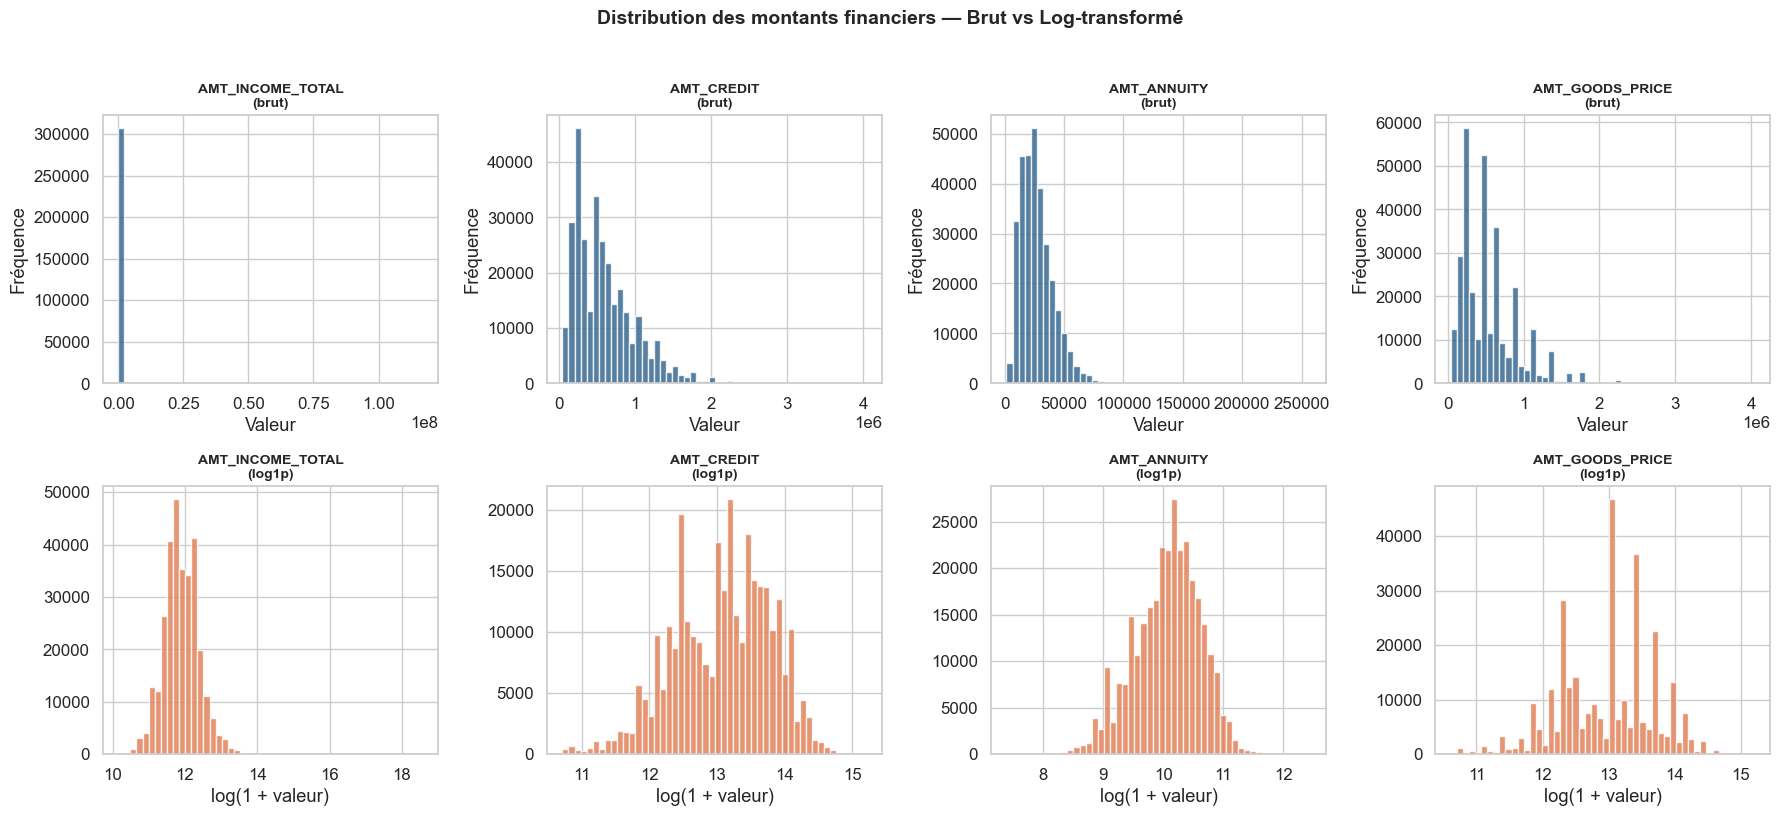

In [16]:
# ── Features financières clés ─────────────────────────────────────────────────
financial_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(financial_cols):
    data = df[col].dropna()
    
    # Histogramme brut
    axes[0, i].hist(data, bins=50, color=COLOR_NEG, edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(brut)', fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel('Valeur')
    axes[0, i].set_ylabel('Fréquence')
    
    # Histogramme log-transformé
    log_data = np.log1p(data)
    axes[1, i].hist(log_data, bins=50, color=COLOR_POS, edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(log1p)', fontsize=10, fontweight='bold')
    axes[1, i].set_xlabel('log(1 + valeur)')

plt.suptitle('Distribution des montants financiers — Brut vs Log-transformé', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_financial_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 🔎 INTERPRÉTATION
# Les distributions financières sont fortement asymétriques à droite (right-skewed).
# La transformation log1p rend la distribution plus gaussienne :
#   → Améliore les performances des modèles linéaires et de la régression logistique
#   → Réduit l'impact des outliers (revenus très élevés)
# À appliquer dans le Feature Engineering (notebook 02).
# ─────────────────────────────────────────────────────────────────────────────

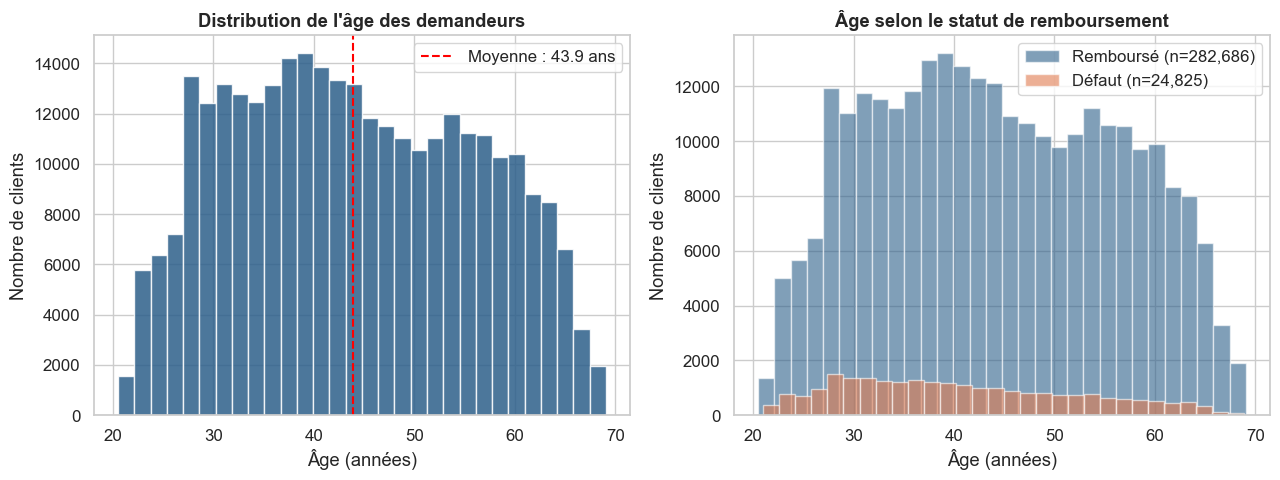

Test t de Student — Âge par classe :
  Classe 0 : âge moyen = 44.2 ans
  Classe 1 : âge moyen = 40.8 ans
  t = 43.52, p-value = 0.00e+00
  → Différence statistiquement significative : OUI  (seuil α = 0.05)


In [17]:
# ── Analyse de l'âge (DAYS_BIRTH) ────────────────────────────────────────────
# Dans ce dataset, les jours sont en valeurs NÉGATIVES (jours avant la demande)
# On les convertit en âge en années pour l'interprétabilité

df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution globale
axes[0].hist(df['AGE_YEARS'], bins=30, color=COLOR_NEG, edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution de l\'âge des demandeurs', fontweight='bold')
axes[0].set_xlabel('Âge (années)')
axes[0].set_ylabel('Nombre de clients')
axes[0].axvline(df['AGE_YEARS'].mean(), color='red', linestyle='--', label=f'Moyenne : {df["AGE_YEARS"].mean():.1f} ans')
axes[0].legend()

# Distribution par classe TARGET
for target, color, label in [(0, COLOR_NEG, 'Remboursé'), (1, COLOR_POS, 'Défaut')]:
    subset = df[df['TARGET'] == target]['AGE_YEARS']
    axes[1].hist(subset, bins=30, color=color, alpha=0.6, label=f'{label} (n={len(subset):,})', edgecolor='white')

axes[1].set_title('Âge selon le statut de remboursement', fontweight='bold')
axes[1].set_xlabel('Âge (années)')
axes[1].set_ylabel('Nombre de clients')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/fig_age_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# Test statistique : est-ce que l'âge est significativement différent entre classes ?
age_class0 = df[df['TARGET'] == 0]['AGE_YEARS'].dropna()
age_class1 = df[df['TARGET'] == 1]['AGE_YEARS'].dropna()
t_stat, p_val = stats.ttest_ind(age_class0, age_class1)
print(f'Test t de Student — Âge par classe :')
print(f'  Classe 0 : âge moyen = {age_class0.mean():.1f} ans')
print(f'  Classe 1 : âge moyen = {age_class1.mean():.1f} ans')
print(f'  t = {t_stat:.2f}, p-value = {p_val:.2e}')
print(f'  → Différence statistiquement significative : {"OUI" if p_val < 0.05 else "NON"}  (seuil α = 0.05)')

# ─────────────────────────────────────────────────────────────────────────────
# 🔎 INTERPRÉTATION
# Les clients plus jeunes tendent à présenter un risque de défaut légèrement plus élevé.
# Le test de Student confirme si cette différence est statistiquement significative
# (p < 0.05 → on rejette H0 : les moyennes sont égales).
# L'âge est donc une feature potentiellement discriminante pour notre modèle.
# ─────────────────────────────────────────────────────────────────────────────

## 6. Analyse des features catégorielles

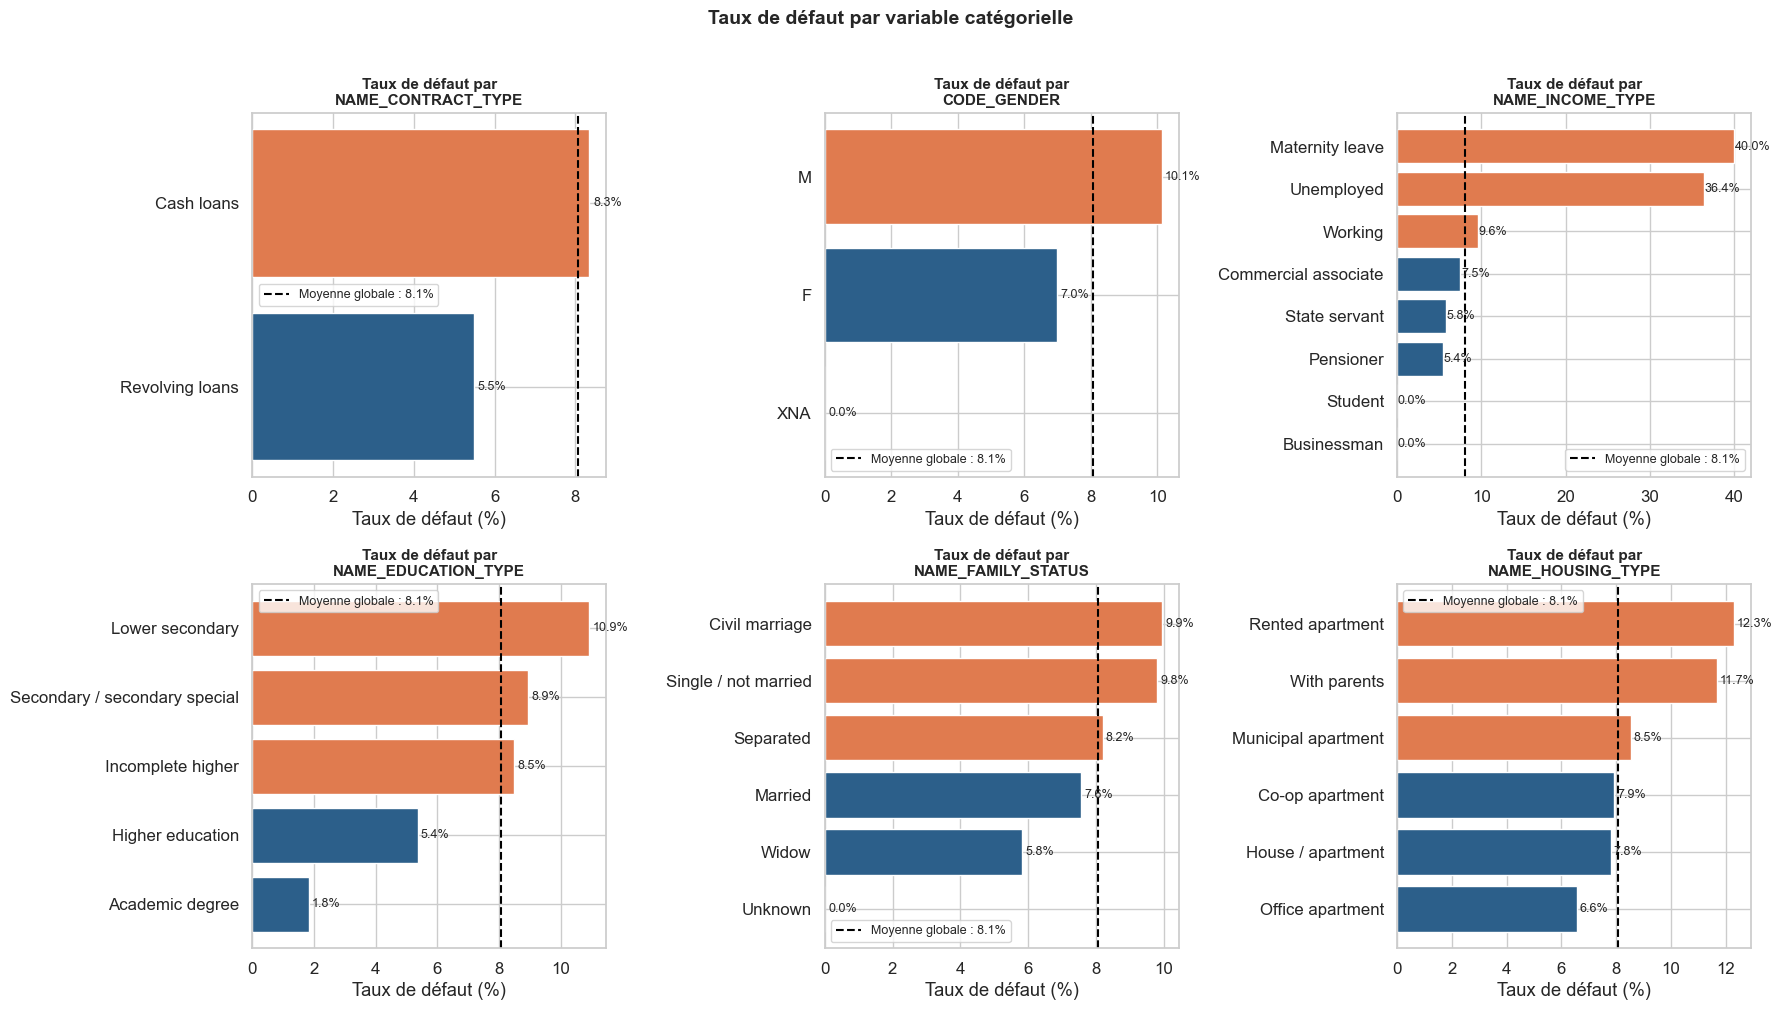

In [18]:
# ── Top features catégorielles par taux de défaut ────────────────────────────
# Pour chaque variable catégorielle, on calcule le taux de défaut par modalité.
# Cela permet d'identifier les variables les plus discriminantes.

important_cat = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE',
                 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(important_cat):
    # Calcul du taux de défaut par catégorie
    default_rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=True) * 100
    
    bars = axes[i].barh(default_rate.index, default_rate.values,
                         color=[COLOR_POS if v > df['TARGET'].mean()*100 else COLOR_NEG 
                                for v in default_rate.values],
                         edgecolor='white')
    
    # Ligne de référence = taux moyen global
    axes[i].axvline(df['TARGET'].mean() * 100, color='black', linestyle='--', 
                    linewidth=1.5, label=f'Moyenne globale : {df["TARGET"].mean()*100:.1f}%')
    
    # Valeurs sur les barres
    for bar, val in zip(bars, default_rate.values):
        axes[i].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
    
    axes[i].set_title(f'Taux de défaut par\n{col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Taux de défaut (%)')
    axes[i].legend(fontsize=9)

plt.suptitle('Taux de défaut par variable catégorielle', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_categorical_default_rate.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Corrélations avec la variable cible

On utilise la corrélation de **Pearson** pour les features numériques afin d'identifier celles qui sont les plus liées à `TARGET`.  
> ⚠️ Une corrélation faible ne signifie pas qu'une feature est inutile — les modèles non-linéaires (Random Forest, XGBoost) peuvent capturer des relations complexes.

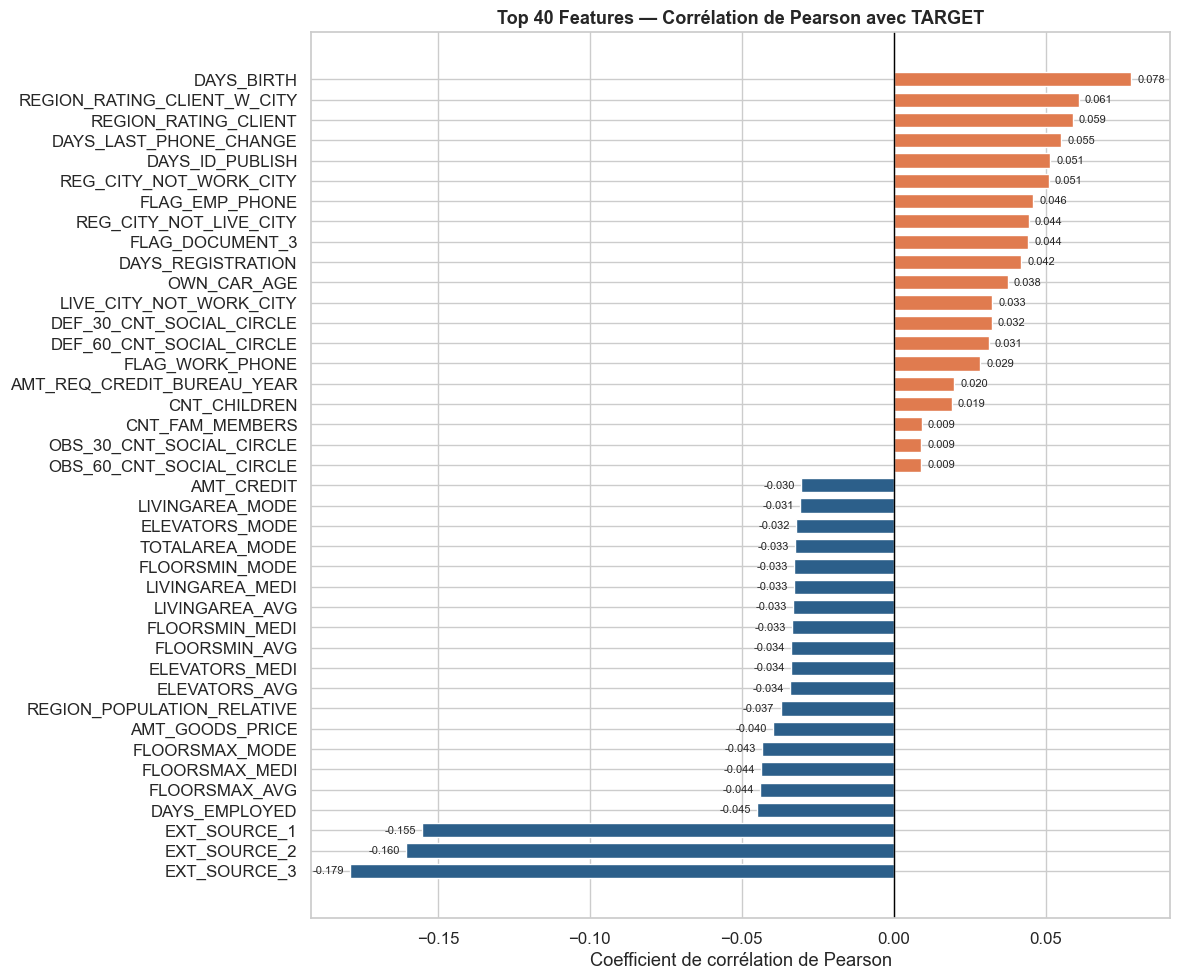


✅ Top 10 features positivement corrélées avec le défaut :
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239

✅ Top 10 features négativement corrélées avec le défaut :
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199


In [19]:
# ── Corrélation de Pearson avec TARGET ────────────────────────────────────────
correlations = df[num_cols].corr()['TARGET'].drop('TARGET').sort_values()

# Top 20 positives + top 20 négatives
top_pos = correlations.tail(20)
top_neg = correlations.head(20)
top_corr = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(12, 10))
colors = [COLOR_NEG if v < 0 else COLOR_POS for v in top_corr.values]
bars = ax.barh(top_corr.index, top_corr.values, color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 40 Features — Corrélation de Pearson avec TARGET', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Coefficient de corrélation de Pearson')

# Annotations
for bar, val in zip(bars, top_corr.values):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n✅ Top 10 features positivement corrélées avec le défaut :')
print(top_pos.tail(10).to_string())
print('\n✅ Top 10 features négativement corrélées avec le défaut :')
print(top_neg.head(10).to_string())

## 8. Analyse des DAYS_ features

Plusieurs colonnes encodent des durées en **jours négatifs** (nombre de jours avant la demande).  
Ex : `DAYS_EMPLOYED = -1000` signifie que le client travaille depuis 1000 jours.  
⚠️ `DAYS_EMPLOYED = 365243` est une valeur aberrante codée pour les retraités/sans emploi.

In [20]:
# ── Anomalie DAYS_EMPLOYED ────────────────────────────────────────────────────
days_cols = [c for c in df.columns if c.startswith('DAYS_')]
print('Colonnes DAYS_ :', days_cols)

# Valeur anormale dans DAYS_EMPLOYED
print(f'\nDAYS_EMPLOYED — valeur max : {df["DAYS_EMPLOYED"].max():,}')
print(f'→ {(df["DAYS_EMPLOYED"] == 365243).sum():,} clients avec DAYS_EMPLOYED = 365243')
print('→ Cette valeur (≈ 1000 ans) est un placeholder pour les sans-emploi/retraités')

# Taux de défaut avec vs sans anomalie
mask_anomaly = df['DAYS_EMPLOYED'] == 365243
print(f'\nTaux de défaut :')
print(f'  Clients AVEC DAYS_EMPLOYED = 365243 : {df[mask_anomaly]["TARGET"].mean()*100:.2f}%')
print(f'  Clients SANS cette anomalie         : {df[~mask_anomaly]["TARGET"].mean()*100:.2f}%')

# ─────────────────────────────────────────────────────────────────────────────
# 🔎 INTERPRÉTATION
# La valeur 365243 est un indicateur fort : les clients sans emploi ou retraités
# ont un profil de risque distinct. Dans le Feature Engineering :
#   → Créer un flag binaire : DAYS_EMPLOYED_ANOM = 1 si valeur = 365243
#   → Remplacer 365243 par NaN, puis imputer
# ─────────────────────────────────────────────────────────────────────────────

Colonnes DAYS_ : ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']

DAYS_EMPLOYED — valeur max : 365,243
→ 55,374 clients avec DAYS_EMPLOYED = 365243
→ Cette valeur (≈ 1000 ans) est un placeholder pour les sans-emploi/retraités

Taux de défaut :
  Clients AVEC DAYS_EMPLOYED = 365243 : 5.40%
  Clients SANS cette anomalie         : 8.66%


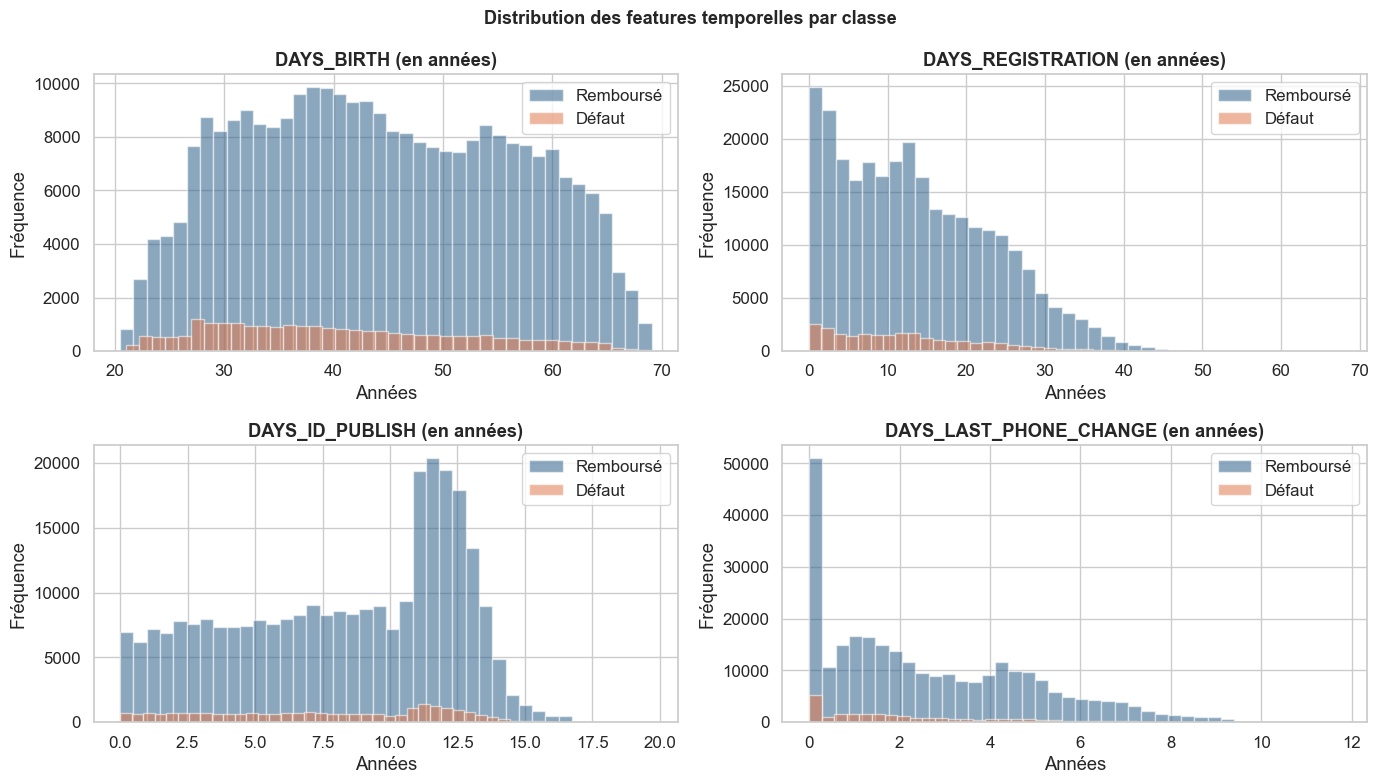

In [21]:
# ── Visualisation des DAYS_ features ─────────────────────────────────────────
days_to_plot = ['DAYS_BIRTH', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(days_to_plot):
    data = df[col].dropna()
    # Convertir en valeur positive (années pour DAYS_BIRTH, années pour les autres)
    data_years = -data / 365.25
    
    for target, color, label in [(0, COLOR_NEG, 'Remboursé'), (1, COLOR_POS, 'Défaut')]:
        subset = data_years[df['TARGET'] == target]
        axes[i].hist(subset, bins=40, color=color, alpha=0.55, label=label, edgecolor='white')
    
    axes[i].set_title(f'{col} (en années)', fontweight='bold')
    axes[i].set_xlabel('Années')
    axes[i].set_ylabel('Fréquence')
    axes[i].legend()

plt.suptitle('Distribution des features temporelles par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_days_features.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Matrice de corrélation inter-features

On identifie les features fortement corrélées entre elles (**multicolinéarité**).  
Une corrélation |r| > 0.85 entre deux features indique que l'une d'elles est potentiellement redondante.  
Cela sera géré dans le Feature Engineering avec le **VIF** (Variance Inflation Factor).

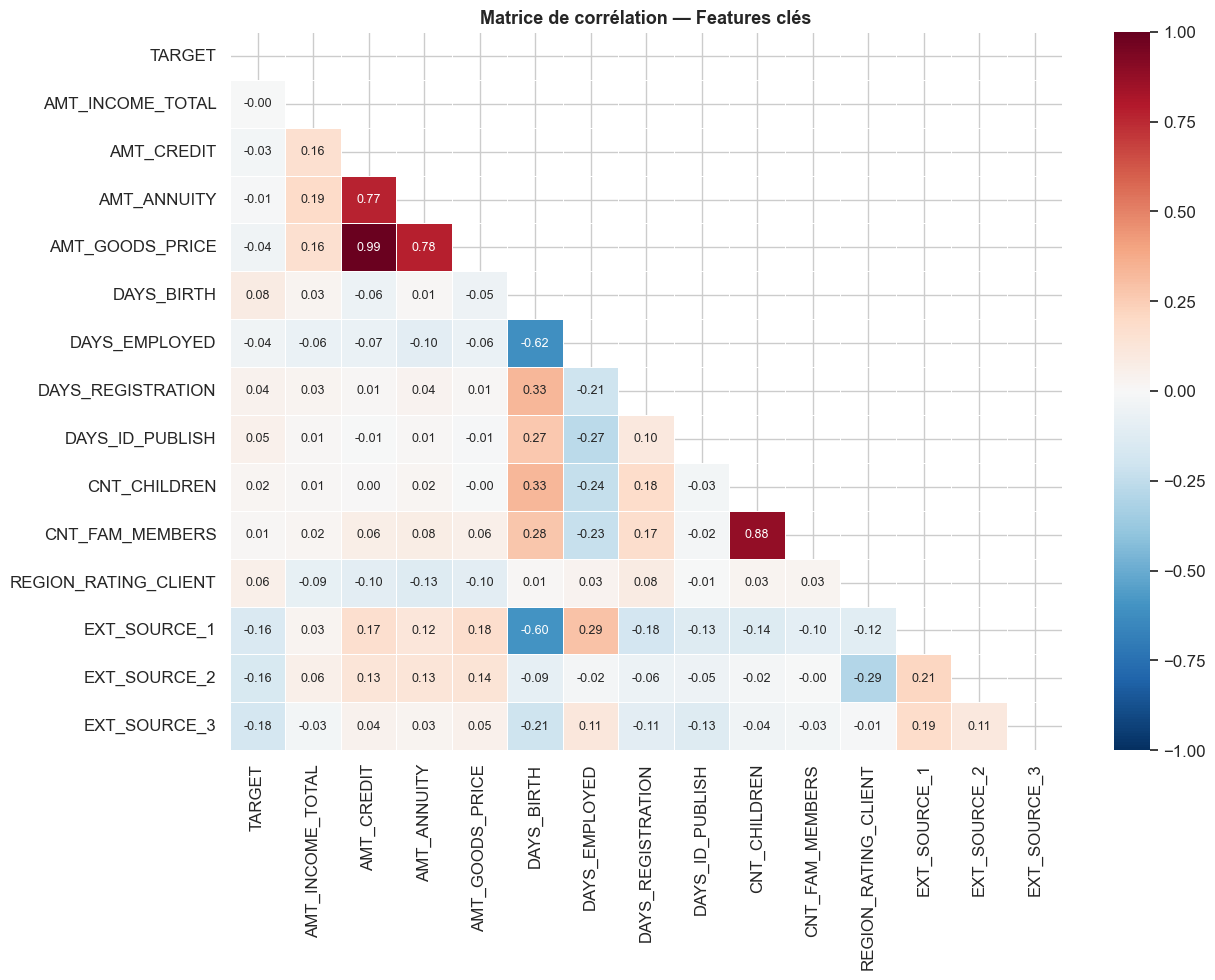


🔎 Paires de features avec |corr| > 0.5 (hors TARGET) :
  AMT_CREDIT ↔ AMT_ANNUITY : r = 0.770
  AMT_CREDIT ↔ AMT_GOODS_PRICE : r = 0.987
  AMT_ANNUITY ↔ AMT_GOODS_PRICE : r = 0.775
  DAYS_BIRTH ↔ DAYS_EMPLOYED : r = -0.616
  DAYS_BIRTH ↔ EXT_SOURCE_1 : r = -0.601
  CNT_CHILDREN ↔ CNT_FAM_MEMBERS : r = 0.879


In [22]:
# ── Sélection des features numériques clés pour la heatmap ───────────────────
key_features = [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

# Filtrer sur les colonnes disponibles
available = [c for c in key_features if c in df.columns]
corr_matrix = df[available].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masque triangle supérieur
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Matrice de corrélation — Features clés', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/fig_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# Paires fortement corrélées
print('\n🔎 Paires de features avec |corr| > 0.5 (hors TARGET) :')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        c1, c2 = corr_matrix.columns[i], corr_matrix.columns[j]
        if c1 != 'TARGET' and c2 != 'TARGET':
            r = corr_matrix.loc[c1, c2]
            if abs(r) > 0.5:
                high_corr.append((c1, c2, r))
                print(f'  {c1} ↔ {c2} : r = {r:.3f}')

## 10. Analyse des EXT_SOURCE (scores externes)

Les variables `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` sont des **scores de crédit externes** (bureau de crédit).  
Ce sont souvent les features les plus prédictives dans ce dataset.

EXT_SOURCE_1 :
  Missing : 56.4%
  Corr avec TARGET : -0.1553

EXT_SOURCE_2 :
  Missing : 0.2%
  Corr avec TARGET : -0.1605

EXT_SOURCE_3 :
  Missing : 19.8%
  Corr avec TARGET : -0.1789



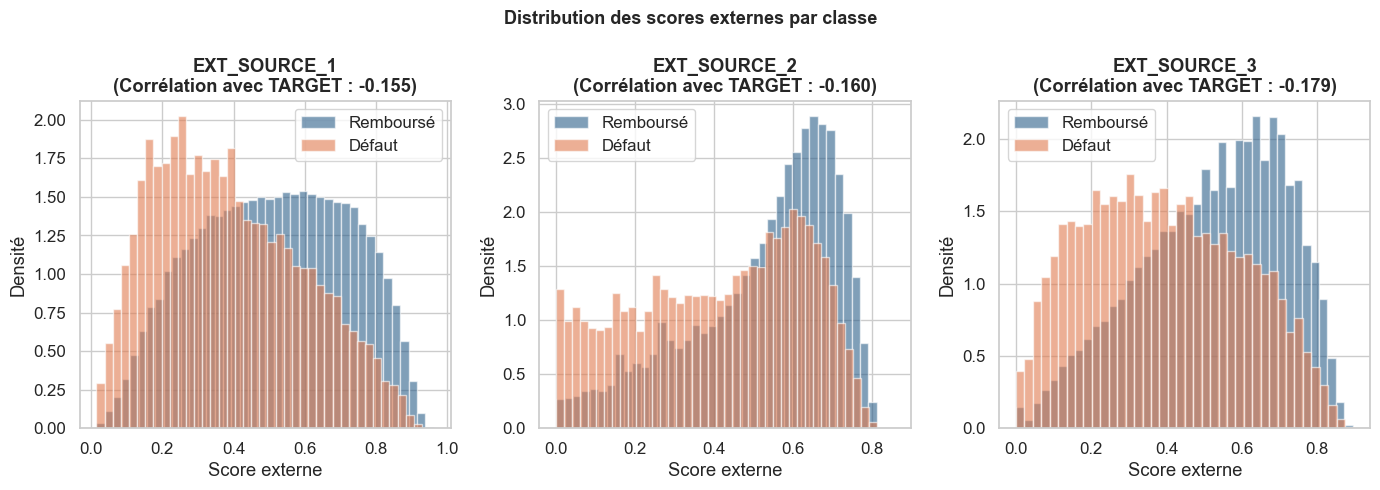

In [23]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_available = [c for c in ext_cols if c in df.columns]

fig, axes = plt.subplots(1, len(ext_available), figsize=(14, 5))

for i, col in enumerate(ext_available):
    for target, color, label in [(0, COLOR_NEG, 'Remboursé'), (1, COLOR_POS, 'Défaut')]:
        subset = df[df['TARGET'] == target][col].dropna()
        axes[i].hist(subset, bins=40, color=color, alpha=0.6, label=label, edgecolor='white', density=True)
    
    axes[i].set_title(f'{col}\n(Corrélation avec TARGET : {df[col].corr(df["TARGET"]):.3f})',
                      fontweight='bold')
    axes[i].set_xlabel('Score externe')
    axes[i].set_ylabel('Densité')
    axes[i].legend()
    
    print(f'{col} :')
    print(f'  Missing : {df[col].isnull().mean()*100:.1f}%')
    print(f'  Corr avec TARGET : {df[col].corr(df["TARGET"]):.4f}')
    print()

plt.suptitle('Distribution des scores externes par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_ext_sources.png', bbox_inches='tight', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 🔎 INTERPRÉTATION
# Les EXT_SOURCE sont des scores externes entre 0 et 1.
# Un score élevé → faible risque de défaut (corrélation négative avec TARGET).
# EXT_SOURCE_2 et EXT_SOURCE_3 ont peu de valeurs manquantes → très exploitables.
# Feature Engineering : créer une moyenne pondérée des EXT_SOURCE disponibles.
# ─────────────────────────────────────────────────────────────────────────────

## 11. Récapitulatif EDA — Synthèse des insights

In [24]:
print('=' * 70)
print('RÉCAPITULATIF EDA — HOME CREDIT DEFAULT RISK')
print('=' * 70)

print(f"""
📦 DATASET
   • {df.shape[0]:,} demandes de crédit | {df.shape[1]} features
   • Variable cible : TARGET (0 = remboursé, 1 = défaut)

⚠️  DÉSÉQUILIBRE DE CLASSES
   • Classe 0 (remboursé) : {(df['TARGET']==0).sum():,} ({(df['TARGET']==0).mean()*100:.1f}%)
   • Classe 1 (défaut)    : {(df['TARGET']==1).sum():,} ({(df['TARGET']==1).mean()*100:.1f}%)
   → Techniques à appliquer : SMOTE, class_weight='balanced'
   → Métriques adaptées : AUC-ROC, F1-Score, Score Métier pondéré

🔍 VALEURS MANQUANTES
   • {len(missing_nonzero)} colonnes avec des valeurs manquantes
   • Colonnes à >50% missing → à supprimer ou indicateur binaire
   • DAYS_EMPLOYED = 365243 → anomalie à flagguer et imputer

📊 FEATURES IMPORTANTES IDENTIFIÉES
   • EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 → très corrélées avec TARGET
   • AGE (DAYS_BIRTH) → les jeunes ont un risque légèrement plus élevé
   • AMT_CREDIT, AMT_INCOME_TOTAL → distributions asymétriques → log-transform
   • NAME_EDUCATION_TYPE, NAME_INCOME_TYPE → fortement discriminantes

🛠️  ACTIONS FEATURE ENGINEERING (notebook 02)
   1. Supprimer colonnes > 60% missing
   2. Créer DAYS_EMPLOYED_ANOM (flag anomalie)
   3. Convertir DAYS_BIRTH → AGE_YEARS
   4. Log-transformer les montants financiers
   5. Créer EXT_SOURCE_MEAN (moyenne des 3 scores)
   6. Encoder les catégorielles (One-Hot pour faible cardinalité, Target Encoding pour haute)
   7. Imputer les NaN (médiane pour numériques, mode pour catégorielles)
""")

print('=' * 70)
print('✅ EDA terminée — Prochaine étape : 02_Feature_Engineering.ipynb')
print('=' * 70)

RÉCAPITULATIF EDA — HOME CREDIT DEFAULT RISK

📦 DATASET
   • 307,511 demandes de crédit | 123 features
   • Variable cible : TARGET (0 = remboursé, 1 = défaut)

⚠️  DÉSÉQUILIBRE DE CLASSES
   • Classe 0 (remboursé) : 282,686 (91.9%)
   • Classe 1 (défaut)    : 24,825 (8.1%)
   → Techniques à appliquer : SMOTE, class_weight='balanced'
   → Métriques adaptées : AUC-ROC, F1-Score, Score Métier pondéré

🔍 VALEURS MANQUANTES
   • 67 colonnes avec des valeurs manquantes
   • Colonnes à >50% missing → à supprimer ou indicateur binaire
   • DAYS_EMPLOYED = 365243 → anomalie à flagguer et imputer

📊 FEATURES IMPORTANTES IDENTIFIÉES
   • EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 → très corrélées avec TARGET
   • AGE (DAYS_BIRTH) → les jeunes ont un risque légèrement plus élevé
   • AMT_CREDIT, AMT_INCOME_TOTAL → distributions asymétriques → log-transform
   • NAME_EDUCATION_TYPE, NAME_INCOME_TYPE → fortement discriminantes

🛠️  ACTIONS FEATURE ENGINEERING (notebook 02)
   1. Supprimer colonnes > 

## 12. Sauvegarde du rapport EDA

On sauvegarde les statistiques clés dans un fichier JSON pour les logguer dans MLFlow plus tard.

In [25]:
import json

eda_report = {
    'n_samples'            : int(df.shape[0]),
    'n_features'           : int(df.shape[1]),
    'target_class_0_count' : int((df['TARGET'] == 0).sum()),
    'target_class_1_count' : int((df['TARGET'] == 1).sum()),
    'target_imbalance_ratio': float((df['TARGET'] == 0).sum() / (df['TARGET'] == 1).sum()),
    'n_numeric_features'   : len(num_cols),
    'n_categorical_features': len(cat_cols),
    'n_columns_with_missing': int(len(missing_nonzero)),
    'days_employed_anomalies': int(mask_anomaly.sum()),
    'top_positive_correlations': top_corr.tail(10).to_dict(),
    'top_negative_correlations': top_corr.head(10).to_dict()
}

with open('../data/processed/eda_report.json', 'w') as f:
    json.dump(eda_report, f, indent=2)

print('✅ Rapport EDA sauvegardé : data/processed/eda_report.json')
print('📊 Graphiques sauvegardés dans : data/processed/')

✅ Rapport EDA sauvegardé : data/processed/eda_report.json
📊 Graphiques sauvegardés dans : data/processed/
